# Soluciones Numericas de EDO


### Forma màs basica : Metodo de Euler 

Ej: si definimos u(t)
\begin{gather}
d²z(t)+w²z(t)=0 \quad u(t)= dz(t) du(t)=d²z(t)=-w²z \\
def: X(t)=[z(t),u(t)] dX=[dz,du]=[u,-w²z]\\
X[0]=z y X[1]=u\\
dX=[X[1]-w²X[0]]
\end{gather}
Dandonos el metodo de euler ocupando la derivada adelanta
\begin{equation}
x(t+h)\simeq x(t)+hf(x(t),t)
\end{equation}

## Ejemplo masa unida a un resorte
\begin{equation}
x=[y(t),u(t)], \quad f=[u(t),-w²y(t)-g], \quad dx=f(x,t)
\end{equation}

In [101]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')

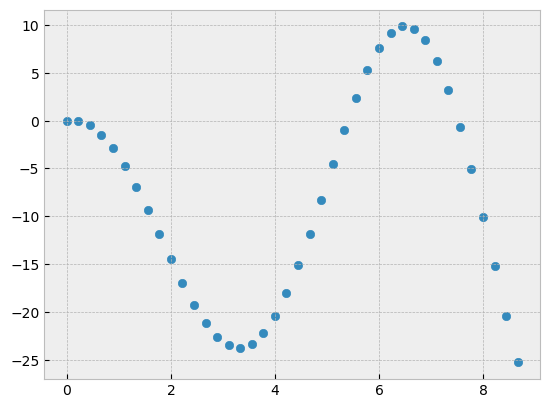

In [102]:
omega = 1.0
g = 9.8
Ntiempo= 40

h=0.000002
def f(x, omega, g = 9.8):
    y, u = x 
    return np.array([u,-g-y*omega**2])

x = np.zeros([Ntiempo, 2])
x[0,0] = 0
x[0,1] = 0
h=0.222

for n in range(Ntiempo-1):
    x[n+1] = x[n] + h*f(x[n], omega, g)
y = x[:,0]
u = x[:,1]
t = np.arange(0,h*Ntiempo,h)
tt = np.linspace(0,h*Ntiempo,40)
plt.scatter(t,y)

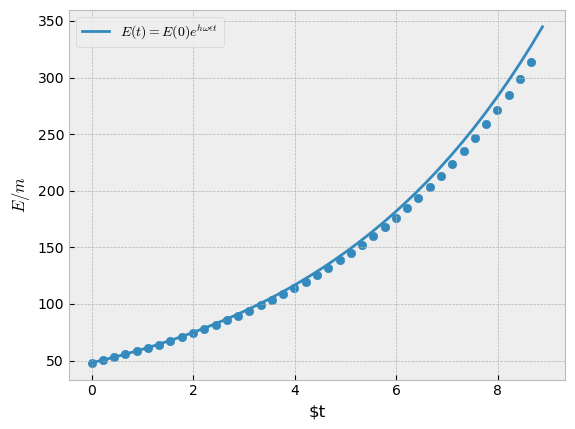

In [103]:
E = u**2/2 + (omega**2/2)*(y+g/omega**2)**2
EE = E[0]*np.exp(omega**2*h*tt)
plt.plot(tt,EE, label='$E(t)=E(0)e^{h\\omega²t}$')
plt.scatter(t,E)
plt.xlabel('$t')
plt.ylabel('$E/m$')
#lt.yscale('log')
plt.legend()

In [104]:
y_EC = np.zeros(Ntiempo)
u_EC = np.zeros(Ntiempo)
y_EC[0] = 0
u_EC[0] = 0

for n in range(Ntiempo-1):
    u_EC[n+1] = u_EC[n] - h*(y_EC[n]*omega**2+g)
    y_EC[n+1] = y_EC[n] + h*u_EC[n+1]


#u[n+1] = u[n]-h*(y[n]*omega**2+g)
#y[n+1] = y[n]+h*u[n+1]

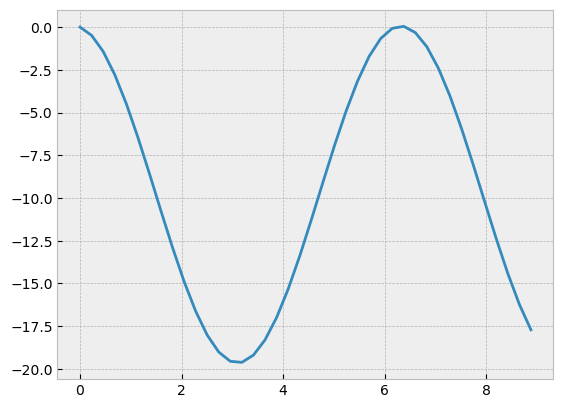

In [105]:
t = np.arange(0,h*Ntiempo)
plt.plot(tt,y_EC)

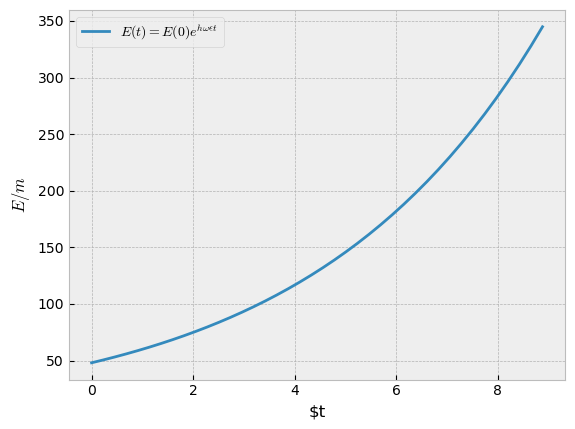

In [108]:
E_EC = u**2/2 + (omega**2/2)*(y+g/omega**2)**2
#EE = E[0]*np.exp(omega**2*h*tt)
plt.plot(tt,EE, label='$E(t)=E(0)e^{h\\omega²t}$')
#plt.scatter(tt,E_EC)
plt.xlabel('$t')
plt.ylabel('$E/m$')
#lt.yscale('log')
plt.legend()